In [15]:
import numpy as np
from matplotlib import pyplot as plt

Define the problem parameters


In [16]:
A = np.array([[1, 3], [3, 1]]) # low dimensions to plot it, you can test larger sizes
b = np.array([-1, 2])

lmbda = 0.5


The function to be minimized is $\frac{1}{2}\|Ax-b\|_2^2 + \lambda \|x\|_1$

In [17]:
f = lambda x: 0.5 * np.sum((A @ x - b) ** 2)
F = lambda x: f(x) + lmbda * np.sum(np.abs(x))

# derivative of f from matrix calculus
df = lambda x: A.T @ (A @ x) - A.T @ b


Plot the function

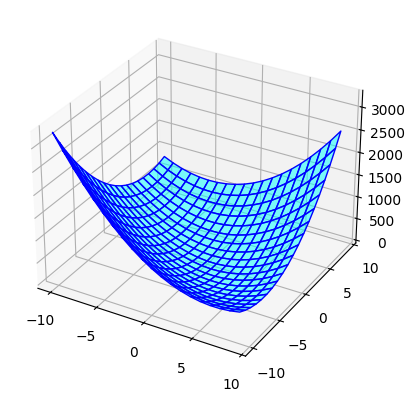

In [18]:
# this function has been prepared only for the visualization sake, no need to go through this but it renders some nice
# graphics :)
Fplot = lambda r1, r2: (r1 * A[0, 0] + r2 * A[0, 1] - b[0]) ** 2 + (r1 * A[1, 0] + r2 * A[1,1] - b[1]) ** 2 + lmbda * (np.abs(r1) + np.abs(r2))
xx, yy = np.meshgrid(np.arange(-10, 10, 1), np.arange(-10, 10, 1))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])

ISTA with backtracking
----------------------------
Parameters of ISTA

In [19]:
MAX_ITER = 1e3
TOL_DIST_X = 1e-6
# initial value for alpha
alpha = 1
# parameter for backtracking
eta = 0.99

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [20]:
x = np.array([-5, 10])

grad_norm = 1e10
distanceX = 1e10

# initialize the list with all the estimates
all_x = [x]
x_past = x

Main loop

In [21]:
def soft_thresholding(x, thresh):
    return np.where(x > thresh, x - thresh, 
           np.where(x < -thresh, x + thresh, 0.0))


cnt = 0
alpha_current = alpha
while cnt < MAX_ITER and distanceX > TOL_DIST_X:
    print(f"{cnt +1} iteration: ")
    # compute the argument of the proximal operator
    x_current = x_past - alpha_current * df(x_past)

    # perform thresholding
    
    x_current = soft_thresholding(x_current, lmbda * alpha_current)

    # iterate the backtracking procedure until the stopping criterion is met
    while f(x_current) > f(x_past) + (df(x_past) @ (x_current - x_past)) + (1/(2* alpha_current)) * np.linalg.norm(x_current-x_past)**2:
        #print(f"Computing the backtracking {alpha_current}... {f(x_current)} > {f(x_past) + df(x_past) @ (x_current - x_past) + (1/(2* alpha_current)) * np.linalg.norm(x_current-x_past)**2}")
        cnt = cnt + 1
      # update alpha
        alpha_current = eta * alpha_current

        # compute again x
        x_current = x_past - alpha_current * df(x_past)

        # perform soft thresholding
        x_current = soft_thresholding(x_current, alpha_current*lmbda)

    # compute the stopping criteria
    distanceX = np.linalg.norm(x_past- x_current)
    print(f"{x_current}")
    # store the estimate
    x_past = x_current
    all_x.append(x_current)
    cnt +=1



1 iteration: 
[-5.41567474  3.39539025]
239 iteration: 
[-1.78688914  3.12198212]
240 iteration: 
[-1.35855954  1.08993432]
241 iteration: 
[-0.19965934  0.69753866]
242 iteration: 
[0.01384612 0.02530665]
243 iteration: 
[ 0.40270512 -0.05192971]
244 iteration: 
[ 0.47517358 -0.27333966]
245 iteration: 
[ 0.60341405 -0.33039285]
246 iteration: 
[ 0.64481679 -0.40581988]
247 iteration: 
[ 0.68977907 -0.43452009]
248 iteration: 
[ 0.70911532 -0.46162887]
249 iteration: 
[ 0.72561484 -0.47441348]
250 iteration: 
[ 0.73395904 -0.48453324]
251 iteration: 
[ 0.74020423 -0.48992979]
252 iteration: 
[ 0.74367155 -0.49380272]
253 iteration: 
[ 0.74608254 -0.49601985]
254 iteration: 
[ 0.74749525 -0.49752522]
255 iteration: 
[ 0.74843734 -0.49842301]
256 iteration: 
[ 0.74900678 -0.49901363]
257 iteration: 
[ 0.74937756 -0.49937429]
258 iteration: 
[ 0.74960573 -0.4996073 ]
259 iteration: 
[ 0.74975228 -0.49975153]
260 iteration: 
[ 0.74984339 -0.49984375]
261 iteration: 
[ 0.74990146 -0.499901

Plot all the estimates

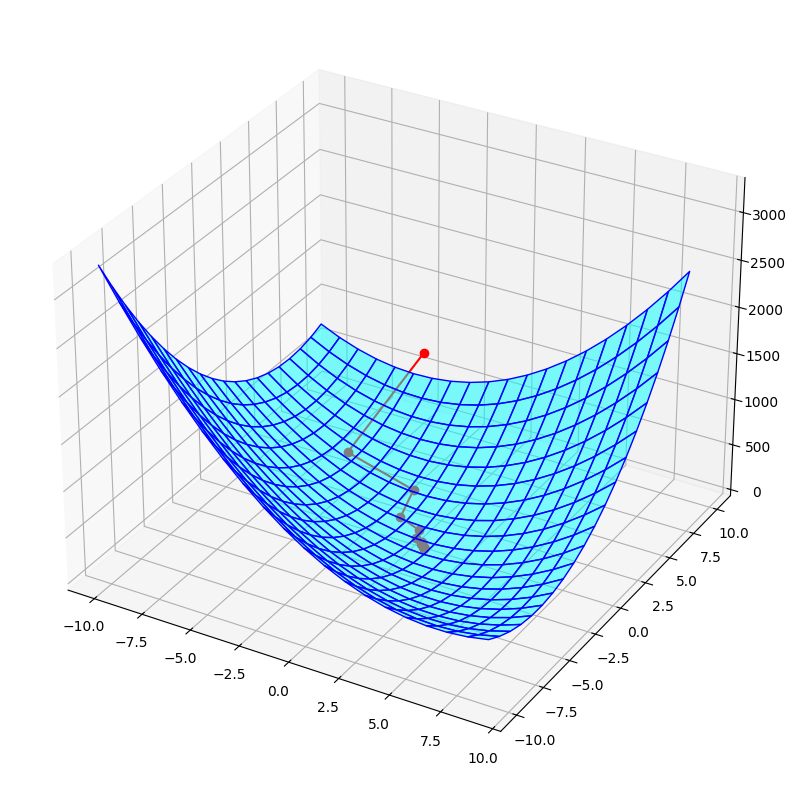

In [22]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = Fplot(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

Compare the number of iteration needed for convergence with backtracking with the number of iteration required using the optimal alpha

In [23]:
print(f'nr of iteration of ISTA with backtracking (before stopping criteria met): {cnt}\n')
print(f'Solution of ISTA: [{x_current[0]:.4f}, {x_current[1]:.4f}]\n')
print(f'Value of the functional: {F(x_current):.4f}\n')

nr of iteration of ISTA with backtracking (before stopping criteria met): 271

Solution of ISTA: [0.7500, -0.5000]

Value of the functional: 0.6875



FISTA
-----
Parameters of FISTA

In [24]:
MAX_ITER = 1e3
TOL_DIST_X = 1e-6
# set the optimal value for alpha
alpha = 1 / np.max(np.linalg.eigvals(A.T@A))

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [25]:
# initialize x
x = np.array([5, 10])

# initialize y
y = x

# initialize gamma
gamma = 1

grad_norm = 1e10
distanceX = 1e10

# initialize the list with all the estimates
all_x = [x]



Main loop

In [26]:
def soft_thresholding(x, thresh):
    return np.where(x > thresh, x - thresh, 
           np.where(x < -thresh, x + thresh, 0.0))


cnt = 0
alpha_current = alpha
while cnt < MAX_ITER and distanceX > TOL_DIST_X:
    # compute the argument of the proximal operator
    x = y - alpha_current * df(y)
    # perform soft thresholding of x
    x = soft_thresholding(x, alpha*lmbda)
    # update gamma
    gamma_past  = gamma
    gamma = (1+np.sqrt(1+4* gamma_past**2))/2
    # update y
    y = x + ((gamma_past - 1) /gamma) * (x- all_x[-1]) 
    # compute the stopping criteria
    distanceX = np.linalg.norm(all_x[-1] - x)   
    # store the estimate
    all_x.append(x)
    print(f"x : {x}, alpha: {alpha_current}")
    cnt +=1


x : [-1.53125  1.78125], alpha: 0.0625
x : [-0.8984375  1.1484375], alpha: 0.0625
x : [-0.29010526  0.54010526], alpha: 0.0625
x : [0.16795272 0.01954728], alpha: 0.0625
x : [ 0.53179236 -0.28179236], alpha: 0.0625
x : [ 0.73570493 -0.48570493], alpha: 0.0625
x : [ 0.83852142 -0.58852142], alpha: 0.0625
x : [ 0.86941707 -0.61941707], alpha: 0.0625
x : [ 0.85621169 -0.60621169], alpha: 0.0625
x : [ 0.82229322 -0.57229322], alpha: 0.0625
x : [ 0.78476773 -0.53476773], alpha: 0.0625
x : [ 0.75405557 -0.50405557], alpha: 0.0625
x : [ 0.73466911 -0.48466911], alpha: 0.0625
x : [ 0.72671263 -0.47671263], alpha: 0.0625
x : [ 0.72762706 -0.47762706], alpha: 0.0625
x : [ 0.7337913 -0.4837913], alpha: 0.0625
x : [ 0.74173465 -0.49173465], alpha: 0.0625
x : [ 0.74886372 -0.49886372], alpha: 0.0625
x : [ 0.75373074 -0.50373074], alpha: 0.0625
x : [ 0.75595108 -0.50595108], alpha: 0.0625
x : [ 0.75591179 -0.50591179], alpha: 0.0625
x : [ 0.75440805 -0.50440805], alpha: 0.0625
x : [ 0.75231309 -0.50

Plot all the estimates

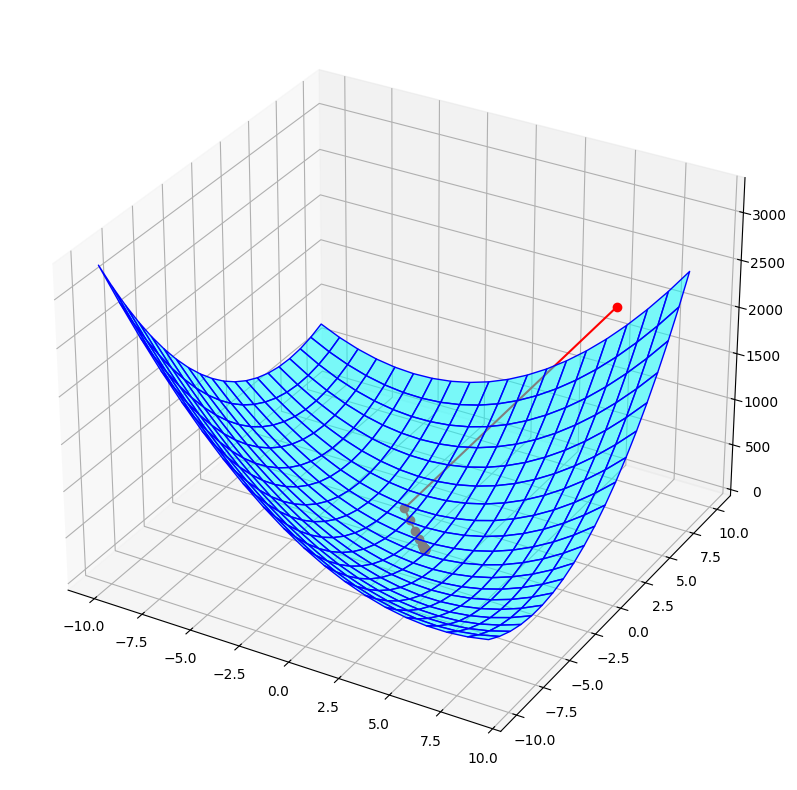

In [27]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = Fplot(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

In [28]:
print(f'nr of iteration of FISTA (before stopping criteria met): {cnt}\n')
print(f'Solution of FISTA: [{x[0]:.4f}, {x[1]:.4f}]\n')
print(f'Value of the functional: {F(x):.4f}\n')

nr of iteration of FISTA (before stopping criteria met): 57

Solution of FISTA: [0.7500, -0.5000]

Value of the functional: 0.6875

